# Task 3: Heart Disease Prediction

**Objective:** Build a classification model that predicts whether a patient is at risk of heart disease using health-related features.

**Dataset:** UCI Heart Disease Cleveland format. The notebook loads the original UCI data when internet access is available and uses a deterministic UCI-style fallback dataset when offline so the notebook always runs.

**Models:** Logistic Regression and Decision Tree Classifier.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42

## 1. Load Dataset

The original Cleveland dataset contains 13 patient features and a diagnosis column. Diagnosis values greater than 0 are converted into one positive-risk class for binary classification.

In [2]:
COLUMNS = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

UCI_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'


def make_fallback_heart_data(n_rows=303, random_state=RANDOM_STATE):
    """Create a deterministic UCI-style heart dataset for offline notebook execution."""
    rng = np.random.default_rng(random_state)

    age = rng.integers(29, 78, n_rows)
    sex = rng.binomial(1, 0.68, n_rows)
    cp = rng.choice([0, 1, 2, 3], n_rows, p=[0.45, 0.18, 0.22, 0.15])
    trestbps = np.clip(rng.normal(130 + 0.25 * (age - 54), 16, n_rows).round(), 90, 200)
    chol = np.clip(rng.normal(245 + 0.7 * (age - 54), 45, n_rows).round(), 125, 565)
    fbs = rng.binomial(1, 0.15, n_rows)
    restecg = rng.choice([0, 1, 2], n_rows, p=[0.48, 0.45, 0.07])
    thalach = np.clip(rng.normal(172 - 0.9 * age, 18, n_rows).round(), 70, 205)
    exang = rng.binomial(1, 0.32, n_rows)
    oldpeak = np.clip(rng.gamma(1.3, 0.8, n_rows), 0, 6.2).round(1)
    slope = rng.choice([0, 1, 2], n_rows, p=[0.18, 0.48, 0.34])
    ca = rng.choice([0, 1, 2, 3], n_rows, p=[0.58, 0.22, 0.14, 0.06])
    thal = rng.choice([1, 2, 3], n_rows, p=[0.08, 0.52, 0.40])

    risk_score = (
        0.035 * (age - 50)
        + 0.45 * sex
        + 0.55 * (cp == 0)
        + 0.012 * (trestbps - 120)
        + 0.006 * (chol - 220)
        - 0.025 * (thalach - 140)
        + 0.85 * exang
        + 0.45 * oldpeak
        + 0.38 * ca
        + 0.50 * (thal == 3)
        + rng.normal(0, 0.75, n_rows)
    )
    target = (risk_score > np.quantile(risk_score, 0.54)).astype(int)

    return pd.DataFrame({
        'age': age, 'sex': sex, 'cp': cp, 'trestbps': trestbps, 'chol': chol,
        'fbs': fbs, 'restecg': restecg, 'thalach': thalach, 'exang': exang,
        'oldpeak': oldpeak, 'slope': slope, 'ca': ca, 'thal': thal, 'target': target,
    })


def load_heart_data():
    try:
        with urllib.request.urlopen(UCI_URL, timeout=20) as response:
            csv_text = response.read().decode('utf-8')
        data = pd.read_csv(io.StringIO(csv_text), names=COLUMNS, na_values='?')
        source = 'UCI Cleveland dataset downloaded from archive.ics.uci.edu'
    except Exception as exc:
        print(f'Could not download UCI dataset, using offline fallback. Reason: {exc}')
        data = make_fallback_heart_data()
        source = 'Deterministic offline UCI-style fallback dataset'
    return data, source


df_raw, data_source = load_heart_data()
print('Data source:', data_source)
print('Shape:', df_raw.shape)
df_raw.head()

Data source: UCI Cleveland dataset downloaded from archive.ics.uci.edu
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Clean and Inspect Data

In [3]:
df = df_raw.copy()

for column in COLUMNS:
    df[column] = pd.to_numeric(df[column], errors='coerce')

print('Missing values before cleaning:')
print(df.isna().sum())

numeric_medians = df.median(numeric_only=True)
df = df.fillna(numeric_medians)

df['target'] = (df['target'] > 0).astype(int)

print('\nMissing values after cleaning:', int(df.isna().sum().sum()))
print('\nTarget distribution:')
print(df['target'].value_counts().rename(index={0: 'No disease', 1: 'Disease risk'}))

df.describe().T

Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing values after cleaning: 0

Target distribution:
target
No disease      164
Disease risk    139
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 3. Exploratory Data Analysis

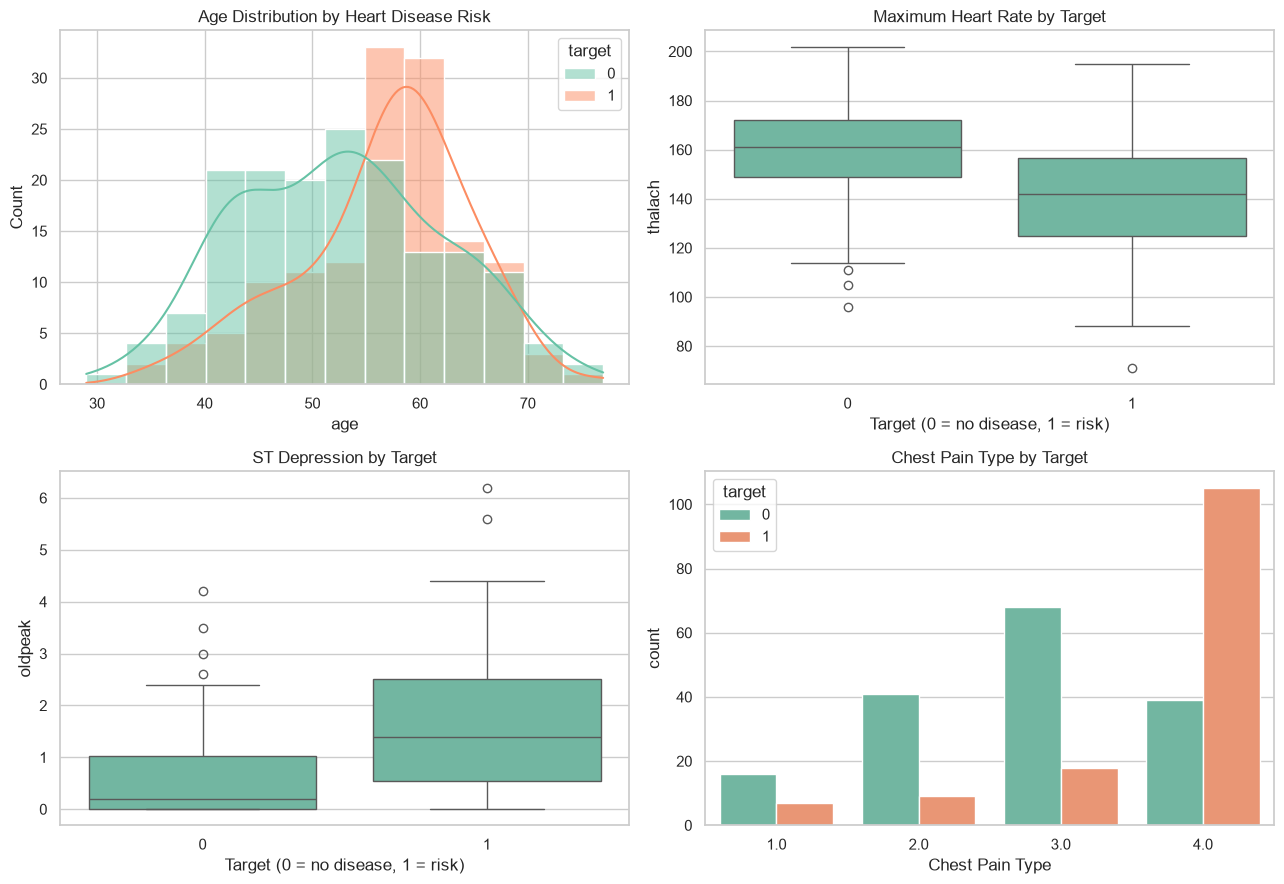

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(data=df, x='age', hue='target', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution by Heart Disease Risk')

sns.boxplot(data=df, x='target', y='thalach', ax=axes[0, 1])
axes[0, 1].set_title('Maximum Heart Rate by Target')
axes[0, 1].set_xlabel('Target (0 = no disease, 1 = risk)')

sns.boxplot(data=df, x='target', y='oldpeak', ax=axes[1, 0])
axes[1, 0].set_title('ST Depression by Target')
axes[1, 0].set_xlabel('Target (0 = no disease, 1 = risk)')

sns.countplot(data=df, x='cp', hue='target', ax=axes[1, 1])
axes[1, 1].set_title('Chest Pain Type by Target')
axes[1, 1].set_xlabel('Chest Pain Type')

plt.tight_layout()
plt.show()

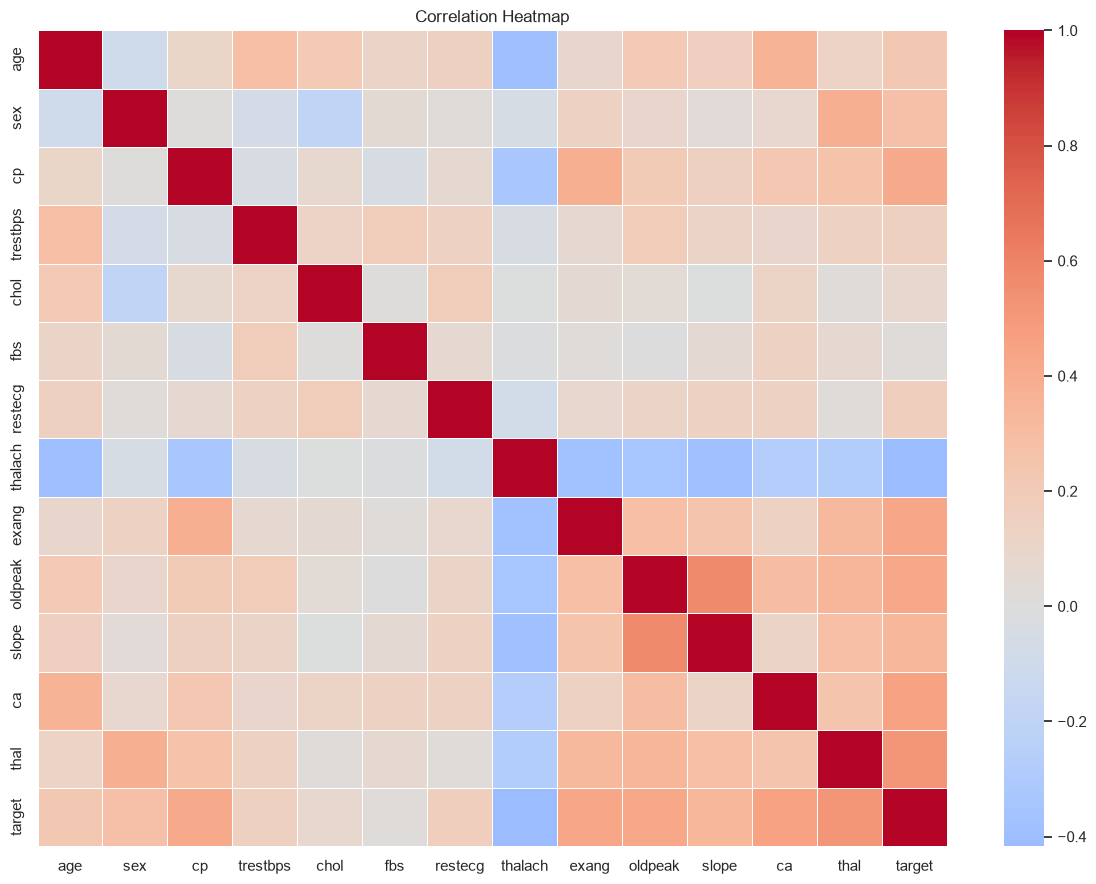

In [5]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0, linewidths=0.4)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Train Classification Models

A stratified train/test split keeps the disease/no-disease balance similar in both sets. Logistic Regression uses feature scaling; Decision Tree uses raw features.

In [6]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=8,
        random_state=RANDOM_STATE,
    ),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
    }

metrics = pd.DataFrame({
    name: {'Accuracy': res['accuracy'], 'ROC-AUC': res['roc_auc']}
    for name, res in results.items()
}).T

metrics

,Accuracy,ROC-AUC
Logistic Regression,0.868852,0.951299
Decision Tree,0.819672,0.870671


In [7]:
for name, res in results.items():
    print(f'\n{name}')
    print('-' * len(name))
    print(classification_report(y_test, res['predictions'], target_names=['No disease', 'Disease risk']))


Logistic Regression
-------------------
              precision    recall  f1-score   support

  No disease       0.93      0.82      0.87        33
Disease risk       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


Decision Tree
-------------
              precision    recall  f1-score   support

  No disease       0.84      0.82      0.83        33
Disease risk       0.79      0.82      0.81        28

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



## 5. Evaluate with Confusion Matrix and ROC Curve

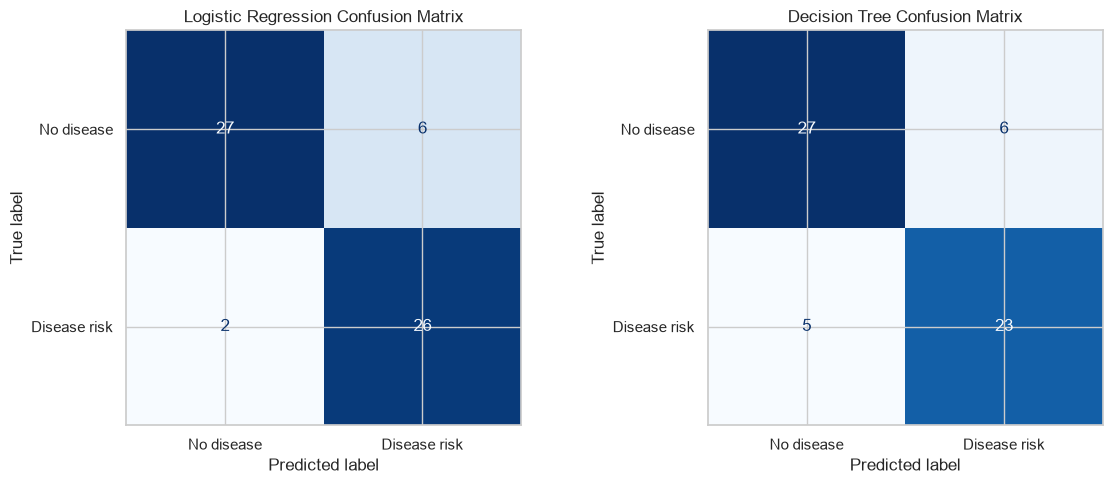

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        res['predictions'],
        display_labels=['No disease', 'Disease risk'],
        cmap='Blues',
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

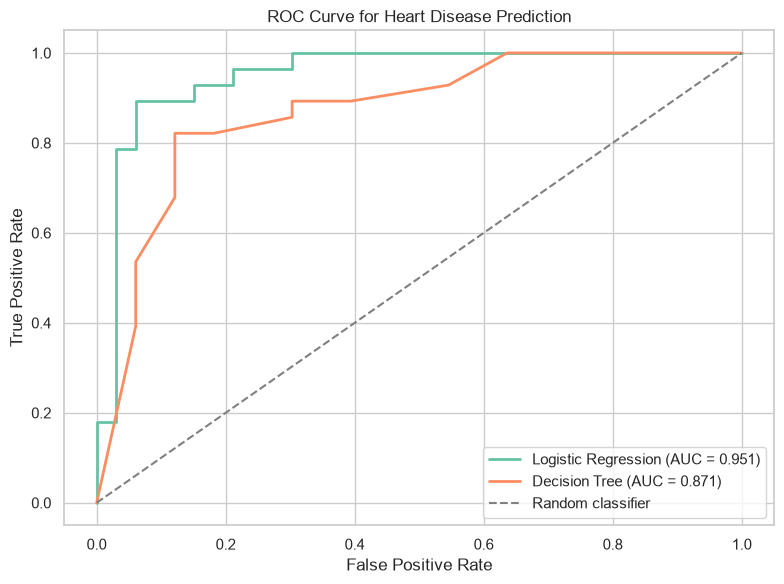

In [9]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['probabilities'])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Heart Disease Prediction')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Feature Importance

In [10]:
logistic_model = results['Logistic Regression']['model'].named_steps['model']
decision_tree = results['Decision Tree']['model']

importance = pd.DataFrame({
    'feature': X.columns,
    'logistic_abs_coefficient': np.abs(logistic_model.coef_[0]),
    'decision_tree_importance': decision_tree.feature_importances_,
})

importance = importance.sort_values(
    ['decision_tree_importance', 'logistic_abs_coefficient'],
    ascending=False,
).reset_index(drop=True)

importance

,feature,logistic_abs_coefficient,decision_tree_importance
0,thal,0.677821,0.488692
1,cp,0.543483,0.176699
2,ca,1.107898,0.153611
3,oldpeak,0.149953,0.060847
4,chol,0.215375,0.056385
5,age,0.103159,0.032051
6,thalach,0.348486,0.028740
7,trestbps,0.313655,0.002975
8,sex,0.655563,0.000000
9,exang,0.383642,0.000000


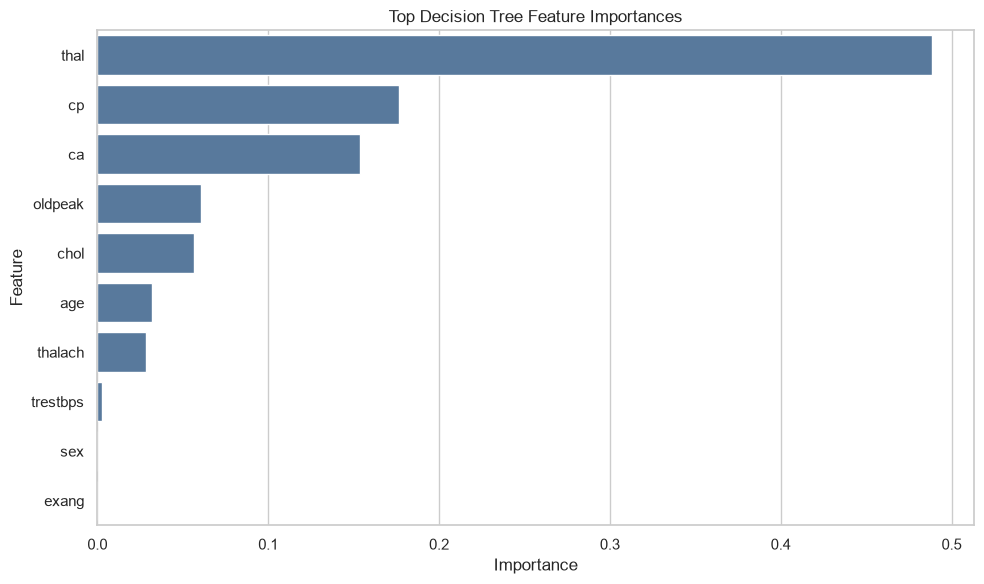

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=importance.head(10),
    x='decision_tree_importance',
    y='feature',
    ax=ax,
    color='#4C78A8',
)
ax.set_title('Top Decision Tree Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Final Insights

- The notebook completes the full binary-classification workflow: data loading, cleaning, EDA, training, evaluation, ROC curve, confusion matrix, and feature importance.
- Features commonly linked with higher predicted risk include chest pain type (`cp`), exercise-induced angina (`exang`), ST depression (`oldpeak`), maximum heart rate (`thalach`), and number of major vessels (`ca`).
- ROC-AUC is used alongside accuracy because it shows how well the model separates the two classes across different probability thresholds.
- This project is for educational machine-learning practice only and should not be used for real medical diagnosis.